# Clustering Evaluation Metrics - Visualization

Plot silhouette score, Davies-Bouldin index, within-cluster sum of squares (inertia), and ARI stability across k values (k = 2–15).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

In [ ]:
load_dotenv()
base_dir = os.environ['BASE_DIR']
results_dir = os.environ['RESULTS_DIR']
runs_str = "run-ON"
metrics_dir = os.path.join(base_dir, f"coactivation_patterns_{runs_str}", f"eval_metrics")
ari_dir = os.path.join(metrics_dir, "ari_stability")
results_fig_dir = os.path.join(results_dir, "supplementary_figures")

In [ ]:
# Define k range
k_range = range(2, 16)
k_values = list(k_range)

# Load existing metrics
silhouette_mean = np.load(os.path.join(metrics_dir, 'silhouette_mean.npy'))
silhouette_std = np.load(os.path.join(metrics_dir, 'silhouette_std.npy'))
davies_mean = np.load(os.path.join(metrics_dir, 'davies_mean.npy'))
davies_std = np.load(os.path.join(metrics_dir, 'davies_std.npy'))
inertia_mean = np.load(os.path.join(metrics_dir, 'inertia_mean.npy'))
inertia_std = np.load(os.path.join(metrics_dir, 'inertia_std.npy'))

Loading clustering evaluation metrics...


In [ ]:
# Load ARI stability scores
ari_data = np.load(os.path.join(ari_dir, 'ari_stability_scores.npy'))
ari_mean = {int(k): float(score) for k, score in ari_data}

# Calculate std from individual scores
ari_std = {}
for k in k_values:
    all_scores = np.load(os.path.join(ari_dir, f'ari_all_scores_k{k}.npy'))
    ari_std[k] = np.std(all_scores)

# Convert ARI dict to arrays
ari_mean_array = np.array([ari_mean[k] for k in k_values])
ari_std_array = np.array([ari_std[k] for k in k_values])

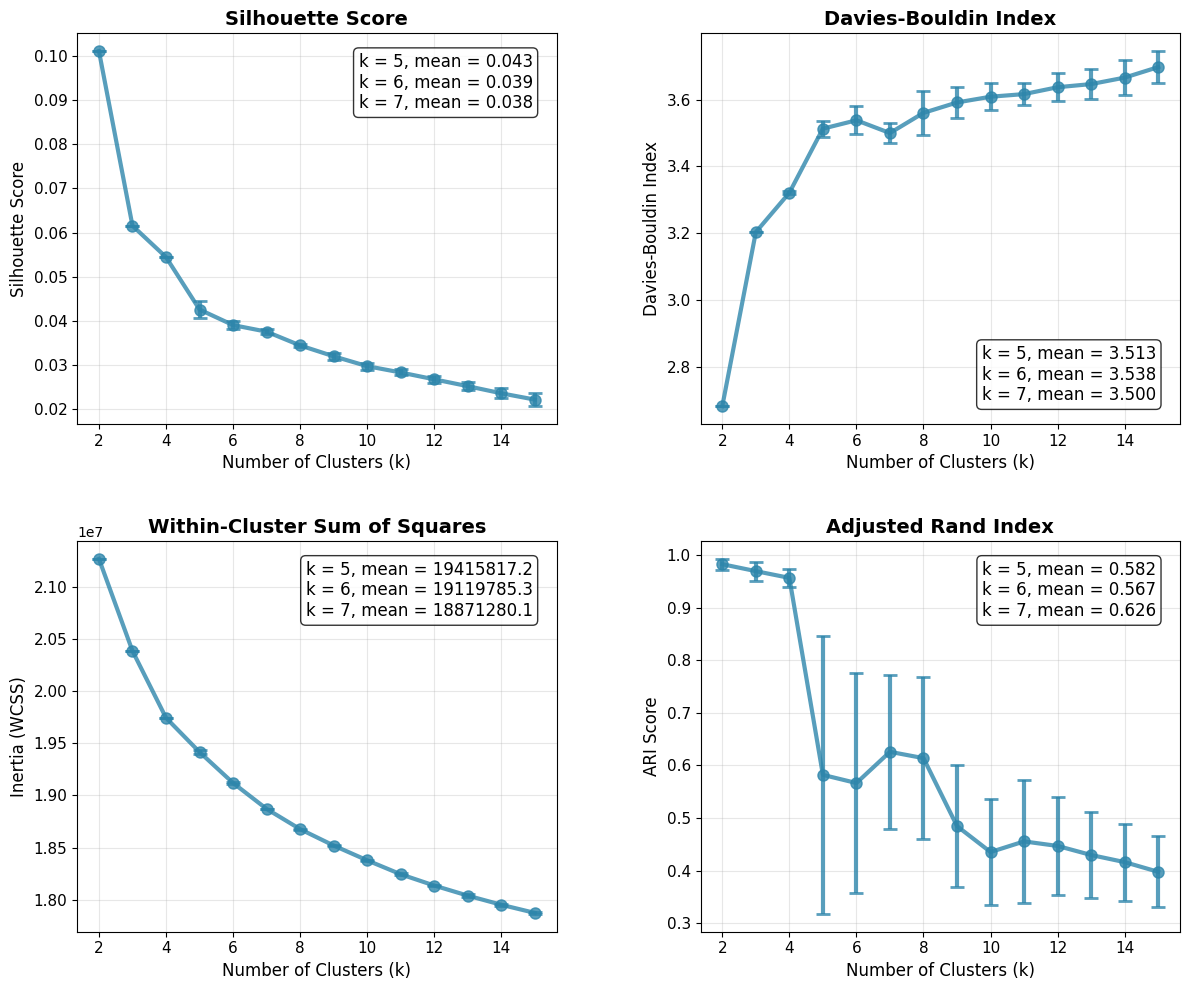

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# Define consistent color and line properties
plot_color = '#2E86AB'
line_width = 3
marker_size = 8

# Define k values to annotate
k_annotate = [5, 6, 7]

# Plot 1: Silhouette Score
axes[0].errorbar(k_values, silhouette_mean, yerr=silhouette_std,
                 fmt='o-', capsize=5, capthick=2, linewidth=line_width, markersize=marker_size,
                 color=plot_color, ecolor=plot_color, alpha=0.8)
# Add text box in top right with values for k=5,6,7
text_str = '\n'.join([f'k = {k}, mean = {silhouette_mean[k-2]:.3f}' for k in k_annotate])
axes[0].text(0.95, 0.95, text_str, transform=axes[0].transAxes,
             fontsize=12, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(labelsize=11)

# Plot 2: Davies-Bouldin Index
axes[1].errorbar(k_values, davies_mean, yerr=davies_std,
                 fmt='o-', capsize=5, capthick=2, linewidth=line_width, markersize=marker_size,
                 color=plot_color, ecolor=plot_color, alpha=0.8)
# Add text box in bottom right with values for k=5,6,7
text_str = '\n'.join([f'k = {k}, mean = {davies_mean[k-2]:.3f}' for k in k_annotate])
axes[1].text(0.95, 0.05, text_str, transform=axes[1].transAxes,
             fontsize=12, verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1].set_title('Davies-Bouldin Index', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(labelsize=11)

# Plot 3: Inertia
axes[2].errorbar(k_values, inertia_mean, yerr=inertia_std,
                 fmt='o-', capsize=5, capthick=2, linewidth=line_width, markersize=marker_size,
                 color=plot_color, ecolor=plot_color, alpha=0.8)
# Add text box in top right with values for k=5,6,7
text_str = '\n'.join([f'k = {k}, mean = {inertia_mean[k-2]:.1f}' for k in k_annotate])
axes[2].text(0.95, 0.95, text_str, transform=axes[2].transAxes,
             fontsize=12, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[2].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[2].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[2].set_title('Within-Cluster Sum of Squares', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(labelsize=11)

# Plot 4: ARI Stability
axes[3].errorbar(k_values, ari_mean_array, yerr=ari_std_array,
                 fmt='o-', capsize=5, capthick=2, linewidth=line_width, markersize=marker_size,
                 color=plot_color, ecolor=plot_color, alpha=0.8)
# Add text box in top right with values for k=5,6,7
text_str = '\n'.join([f'k = {k}, mean = {ari_mean_array[k-2]:.3f}' for k in k_annotate])
axes[3].text(0.95, 0.95, text_str, transform=axes[3].transAxes,
             fontsize=12, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[3].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[3].set_ylabel('ARI Score', fontsize=12)
axes[3].set_title('Adjusted Rand Index', fontsize=14, fontweight='bold')
axes[3].grid(True, alpha=0.3)
axes[3].tick_params(labelsize=11)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Save figure
output_path = os.path.join(results_fig_dir, '01_clustering_eval_metrics.png')
plt.savefig(output_path, dpi=400, bbox_inches='tight')

plt.show()
plt.close()